# Визуализация центроидов 

In [1]:
import sys
sys.path.append('../../ep-classification')
sys.path.append('../../experiments')

In [2]:
import os
import pickle

import numpy as np
import pandas as pd
from itertools import compress

In [3]:
from epoching.model.markers import SeveralMovementsMarker
from dataset.dataset import ProcessingSignal
from epoching.model.epoch import Epoch

from smoother import ChannelSmoother
from distance_calculator import DistanceCalculator
from averager import EpochClusterer

from sklearn.cluster import KMeans

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

Позитивные эпохи - сложное нажатие \
Негативные эпохи - нет нажатия

In [5]:
positive_class_marker1 = SeveralMovementsMarker.COMPLEX
negative_class_marker1 = SeveralMovementsMarker.NOMOVEMENTS

In [6]:
with open(f"../../data/processed_signals/signals_control_{positive_class_marker1.name.lower()}-{negative_class_marker1.name.lower()}.p", "rb") as f:
    processed_signals = pickle.load(f)

## Центроиды для сигналов
1. Кластеризуем сигналы позитивных и негативных эпох (по отдельности)
2. Смотрим, как выглядят центроиды кластеров (это одномерные временные ряды) и сигналы, отнесённые к одному кластеру

In [7]:
def get_signals_df(cluster_signals: np.array) -> pd.DataFrame:
    """
    Собираем датафрейм для отрисовки сигналов
    кластера 

    Параметры:
        cluster_signals - массив [n_signals x signal_len]
        сигналов одного кластера
    """
    res = pd.DataFrame({
        'signal': np.repeat(
            np.arange(cluster_signals.shape[0]), 
            cluster_signals.shape[1]
        ),
        'time': np.tile(
            np.arange(cluster_signals.shape[1]), 
            cluster_signals.shape[0]
        ),
        'values': cluster_signals.ravel()
    })
    return res

In [8]:
def plot_cluster_centroid(cluster_signals: np.array, centroid: np.array, 
                          channel: str, cluster_name: str):
    """
    Отрисовываем центроид кластера 
    с поточечным стандартным отклонением

    Параметры:
        cluster_signals - массив [n_signals x signal_len]
        сигналов одного кластера
        centroid - массив значений [1 x signal_len] сигнала-центроида
        channel - канал, для которого был выделен кластер
        cluster_name - название кластера для названия графика
    """
    time = np.arange(centroid.shape[0])
    
    residuals = cluster_signals - centroid[np.newaxis, :] # [n_signals x signal_len]
    
    sd = np.std(residuals, axis=0, ddof=1)   # [1 x signal_len]
    
    upper = centroid + sd
    lower = centroid - sd

    plt.figure(figsize=(10,4))
    plt.plot(time, centroid, color='C0', label='Centroid')
    plt.fill_between(
        time, lower, upper, 
        color='C0', alpha=0.25, 
        label='±1 SD (around centroid)'
    )
    plt.legend()
    plt.xlabel('Временные метки')
    plt.ylabel(CHANNEL + ' (мкВ)')
    plt.title(cluster_name)
    plt.show()

### KMeans

В KMeans мы выбираем число кластеров заранее

In [9]:
N_CLUSTERS = 3
RANDOM_STATE = 43
CHANNEL = 'C1_laplacian' # канал, по которому кластеризуем
NAME = 'AOC'

In [10]:
# IDX = list(processed_signals[1]).index(NAME)
IDX = 2
IDX

2

#### Позитивные эпохи

In [11]:
smoother = ChannelSmoother(smoothing_channels=[CHANNEL], window_size=10)

In [12]:
pos_epochs = processed_signals[1][NAME]['positive_epochs']
# сглаживаю соответствующий канал
pos_epochs = smoother.smoothe(pos_epochs)

pos_signals_for_channel = np.array([epoch[CHANNEL].tolist() for epoch in pos_epochs])

In [13]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init="auto")

kmeans.fit(pos_signals_for_channel)

pos_labels = kmeans.labels_
pos_centroids = kmeans.cluster_centers_

**Центроиды**

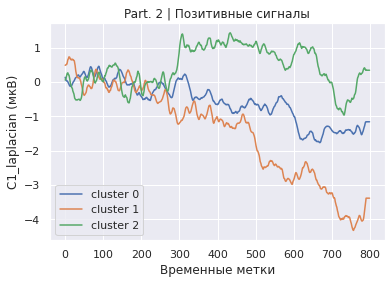

In [14]:
for i in range(len(pos_centroids)):
    plt.plot(pos_centroids[i], label='cluster '+str(i), color=f'C{i}')

plt.xlabel('Временные метки')
plt.ylabel(CHANNEL + ' (мкВ)')
plt.title(f'Part. {IDX} | Позитивные сигналы')
plt.legend()
plt.show()

Несмотря на то что все эти центроиды отражают позитивные эпохи, их поведение сильно разнится: один идет вниз сильно, другой слабо, третий на время возрастает

**Отдельный кластер**

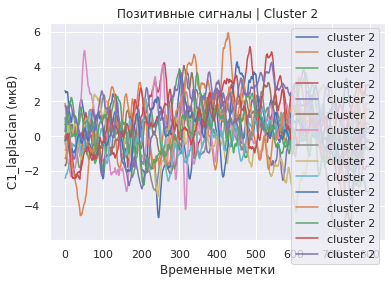

In [15]:
cluster = 2

for signal in pos_signals_for_channel[pos_labels==cluster]:
    plt.plot(signal, label=f'cluster {cluster}')

plt.xlabel('Временные метки')
plt.ylabel(CHANNEL + ' (мкВ)')
plt.legend()
plt.title(f'Позитивные сигналы | Cluster {cluster}')
plt.show()

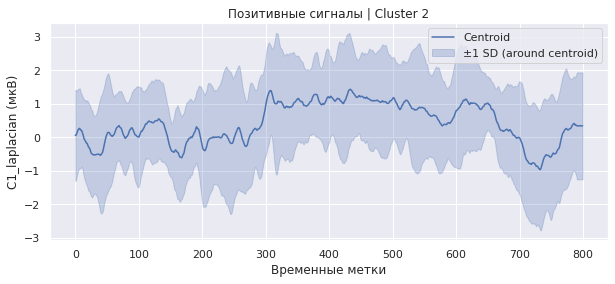

In [16]:
plot_cluster_centroid(
    pos_signals_for_channel[pos_labels==cluster],
    pos_centroids[cluster],
    CHANNEL,
    f'Позитивные сигналы | Cluster {cluster}'
)

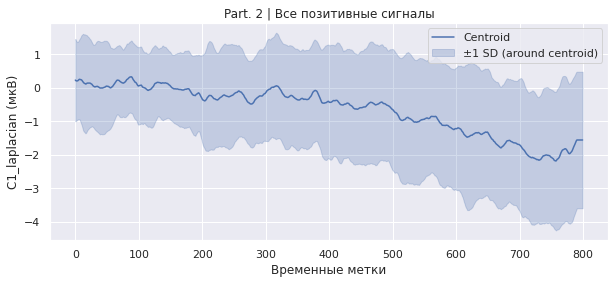

In [17]:
plot_cluster_centroid(
    pos_signals_for_channel,
    pos_signals_for_channel.mean(axis=0),
    CHANNEL,
    f'Part. {IDX} | Все позитивные сигналы'
)

#### Негативные эпохи

In [18]:
neg_epochs = processed_signals[1][NAME]['negative_epochs']
# сглаживаю соответствующий канал
neg_epochs = smoother.smoothe(neg_epochs)

neg_signals_for_channel = np.array([epoch[CHANNEL].tolist() for epoch in neg_epochs])

In [19]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init="auto")

kmeans.fit(neg_signals_for_channel)

neg_labels = kmeans.labels_
neg_centroids = kmeans.cluster_centers_

In [20]:
neg_labels

array([1, 0, 2, 0, 2, 1, 2, 2, 2, 0, 0, 0, 0, 1, 2, 1, 0, 0, 2, 1, 1, 1,
       1, 0, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 0, 2, 2, 0, 1,
       1, 1, 2, 1, 0, 2, 2, 2, 2, 0, 2, 1, 1, 2, 1, 1, 2, 2, 1, 0, 1, 2,
       2, 2, 0, 2, 1, 2, 2, 0, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 1, 2, 1, 0, 1, 0, 1, 2, 2, 1], dtype=int32)

Центроиды

In [21]:
j = i

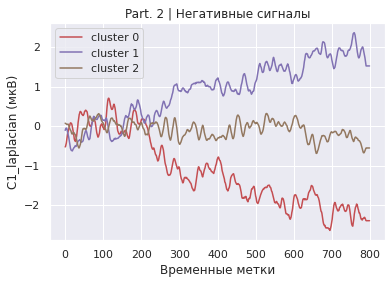

In [22]:
for i in range(len(neg_centroids)):
    plt.plot(neg_centroids[i], label='cluster '+str(i), color=f'C{i+j+1}')

plt.xlabel('Временные метки')
plt.ylabel(CHANNEL + ' (мкВ)')
plt.title(f'Part. {IDX} | Негативные сигналы')
plt.legend()
plt.show()

Отдельный кластер

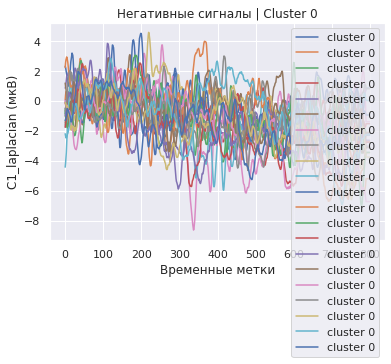

In [23]:
cluster = 0

for signal in neg_signals_for_channel[neg_labels==cluster]:
    plt.plot(signal, label=f'cluster {cluster}')

plt.xlabel('Временные метки')
plt.ylabel(CHANNEL + ' (мкВ)')
plt.legend()
plt.title(f'Негативные сигналы | Cluster {cluster}')
plt.show()

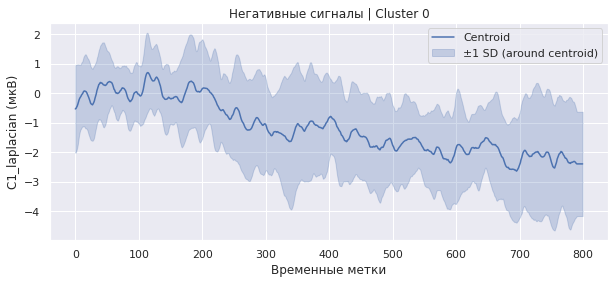

In [24]:
plot_cluster_centroid(
    neg_signals_for_channel[neg_labels==cluster], 
    neg_centroids[cluster],
    CHANNEL, 
    f'Негативные сигналы | Cluster {cluster}'
)

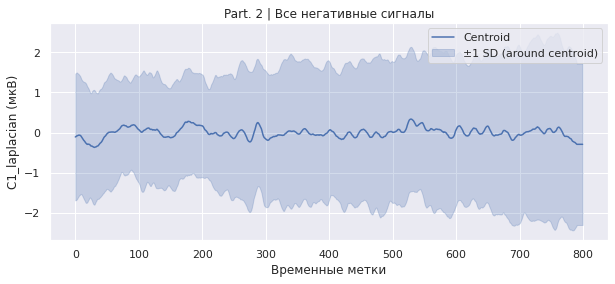

In [25]:
plot_cluster_centroid(
    neg_signals_for_channel,
    neg_signals_for_channel.mean(axis=0),
    CHANNEL,
    f'Part. {IDX} | Все негативные сигналы'
)

По умолчанию считает евклидово расстояние, но можно передать свою матрицу

In [135]:
from sklearn.cluster import AffinityPropagation

### С евклидовым расстоянием

#### Позитивные эпохи

In [24]:
aff_prop = AffinityPropagation(random_state=RANDOM_STATE)

aff_prop.fit(pos_signals_for_channel)

pos_labels = aff_prop.labels_
pos_centroids = aff_prop.cluster_centers_

Центроиды

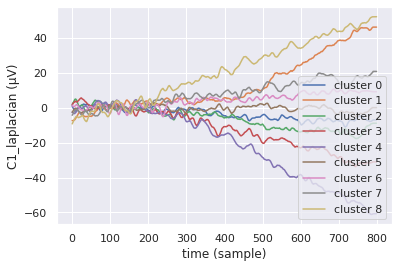

In [25]:
for i in range(len(pos_centroids)):
    plt.plot(pos_centroids[i], label='cluster '+str(i))

plt.xlabel('time (sample)')
plt.ylabel(CHANNEL + ' (μV)')
plt.legend()
plt.show()

Выделилось много кластеров; часть из них лучше было бы объединить

Отдельный кластер

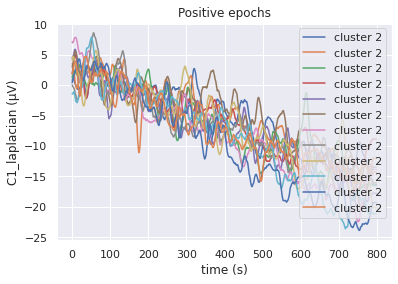

In [26]:
cluster = 2

for signal in pos_signals_for_channel[pos_labels==cluster]:
    plt.plot(signal, label=f'cluster {cluster}')

plt.xlabel('time (s)')
plt.ylabel(CHANNEL + ' (μV)')
plt.legend()
plt.title('Positive epochs')
plt.show()

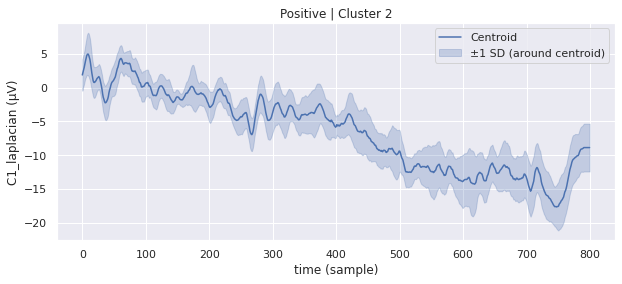

In [27]:
plot_cluster_centroid(
    pos_signals_for_channel[pos_labels==cluster],
    pos_centroids[cluster],
    CHANNEL,
    f'Positive | Cluster {cluster}'
)

#### Негативные эпохи

In [28]:
aff_prop = AffinityPropagation(random_state=RANDOM_STATE)

aff_prop.fit(neg_signals_for_channel)

neg_labels = aff_prop.labels_
neg_centroids = aff_prop.cluster_centers_

Центроиды

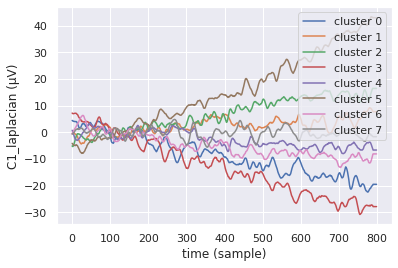

In [29]:
for i in range(len(neg_centroids)):
    plt.plot(neg_centroids[i], label='cluster '+str(i))

plt.xlabel('time (sample)')
plt.ylabel(CHANNEL + ' (μV)')
plt.legend()
plt.show()

Отдельный кластер

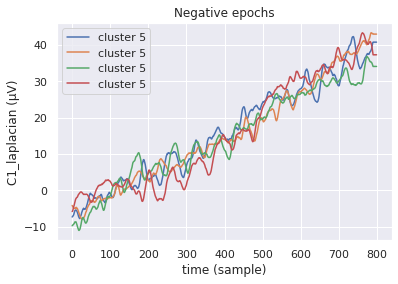

In [30]:
cluster = 5

for signal in neg_signals_for_channel[neg_labels==cluster]:
    plt.plot(signal, label=f'cluster {cluster}')

plt.xlabel('time (sample)')
plt.ylabel(CHANNEL + ' (μV)')
plt.legend()
plt.title('Negative epochs')
plt.show()

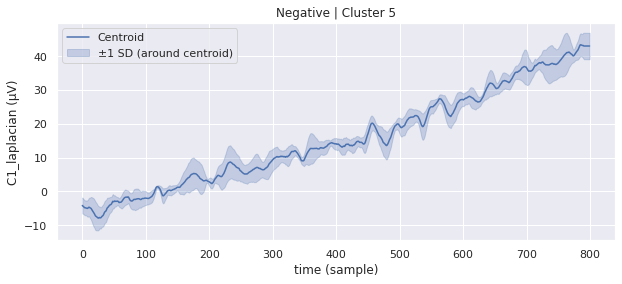

In [31]:
plot_cluster_centroid(
    neg_signals_for_channel[neg_labels==cluster], 
    neg_centroids[cluster],
    CHANNEL, 
    f'Negative | Cluster {cluster}'
)

#### Позитивные эпохи

In [136]:
from scipy.spatial.distance import cdist
from cbd import CompressionBasedDissimilarity

In [158]:
metric = 'correlation'
dist_matrix = cdist(pos_signals_for_channel, pos_signals_for_channel, metric)

upper_without_diag = np.triu(dist_matrix, k=1)
np.fill_diagonal(upper_without_diag, np.min(upper_without_diag[upper_without_diag != 0]))

dist_matrix = np.where(upper_without_diag > 0, upper_without_diag, upper_without_diag.T)

# cbd = CompressionBasedDissimilarity(n_letters=10)

# s = pos_signals_for_channel.shape[0] 
# dist_matrix = -np.zeros((s, s))

# for i in range(s):
#     for j in range(i, s):
#         dist_matrix[i][j] = cbd.calculate(pos_signals_for_channel[i], pos_signals_for_channel[j])

# dist_matrix = np.where(dist_matrix > 0, dist_matrix, dist_matrix.T)

In [159]:
aff_prop = AffinityPropagation(random_state=RANDOM_STATE, affinity='precomputed', damping=0.8)

aff_prop.fit(-dist_matrix)

pos_labels = aff_prop.labels_
pos_centroids_indices = aff_prop.cluster_centers_indices_

Центроиды

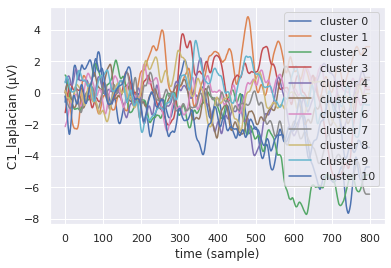

In [160]:
for i in range(len(pos_centroids_indices)):
    ind = pos_centroids_indices[i]
    plt.plot(pos_signals_for_channel[ind], label='cluster '+str(i))

plt.xlabel('time (sample)')
plt.ylabel(CHANNEL + ' (μV)')
plt.legend()
plt.show()

Отдельный кластер

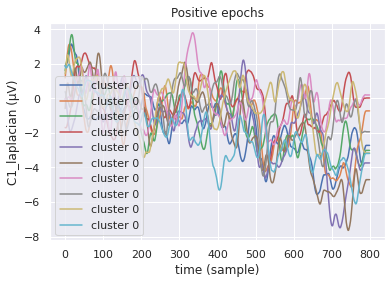

In [141]:
cluster = 0

for signal in pos_signals_for_channel[pos_labels==cluster]:
    plt.plot(signal, label=f'cluster {cluster}')

plt.xlabel('time (sample)')
plt.ylabel(CHANNEL + ' (μV)')
plt.legend()
plt.title('Positive epochs')
plt.show()

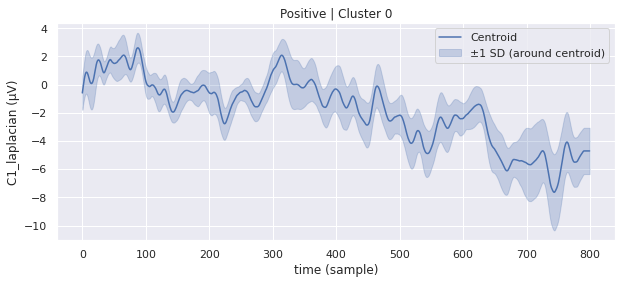

In [142]:
plot_cluster_centroid(
    pos_signals_for_channel[pos_labels==cluster], 
    pos_signals_for_channel[pos_centroids_indices[cluster]],
    CHANNEL, 
    f'Positive | Cluster {cluster}'
)

#### Негативные эпохи

In [143]:
metric = 'correlation'
dist_matrix = cdist(neg_signals_for_channel, neg_signals_for_channel, metric)

upper_without_diag = np.triu(dist_matrix, k=1)
np.fill_diagonal(upper_without_diag, np.min(upper_without_diag[upper_without_diag != 0]))

dist_matrix = np.where(upper_without_diag > 0, upper_without_diag, upper_without_diag.T)

# cbd = CompressionBasedDissimilarity(n_letters=10)

# s = neg_signals_for_channel.shape[0] 
# dist_matrix = -np.empty((s, s))

# for i in range(s):
#     for j in range(i, s):
#         dist_matrix[i][j] = cbd.calculate(neg_signals_for_channel[i], neg_signals_for_channel[j])

# dist_matrix = np.where(dist_matrix > 0, dist_matrix, dist_matrix.T)

In [144]:
dist_matrix

array([[0.32741613, 0.94158658, 1.25480819, ..., 0.95497797, 1.12281377,
        0.97679385],
       [0.94158658, 0.32741613, 1.11917139, ..., 0.85546379, 0.75461511,
        1.10561799],
       [1.25480819, 1.11917139, 0.32741613, ..., 0.81407763, 0.87785021,
        1.09052057],
       ...,
       [0.95497797, 0.85546379, 0.81407763, ..., 0.32741613, 0.68555334,
        1.38570315],
       [1.12281377, 0.75461511, 0.87785021, ..., 0.68555334, 0.32741613,
        0.9042302 ],
       [0.97679385, 1.10561799, 1.09052057, ..., 1.38570315, 0.9042302 ,
        0.32741613]])

In [145]:
aff_prop = AffinityPropagation(random_state=RANDOM_STATE, affinity='precomputed', damping=0.8)

aff_prop.fit(-dist_matrix)

neg_labels = aff_prop.labels_
neg_centroids_indices = aff_prop.cluster_centers_indices_

Центроиды

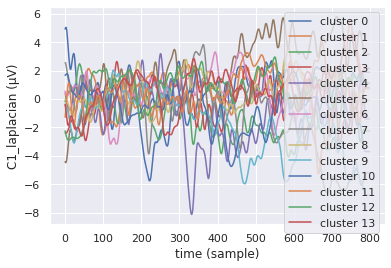

In [146]:
for i in range(len(neg_centroids_indices)):
    ind = neg_centroids_indices[i]
    plt.plot(neg_signals_for_channel[ind], label='cluster '+str(i))

plt.xlabel('time (sample)')
plt.ylabel(CHANNEL + ' (μV)')
plt.legend()
plt.show()

Отдельный кластер

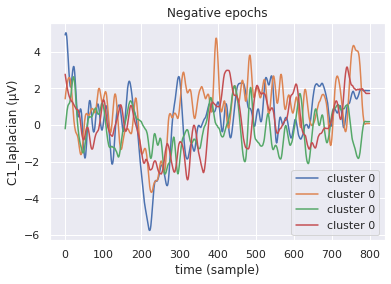

In [147]:
cluster = 0

for signal in neg_signals_for_channel[neg_labels==cluster]:
    plt.plot(signal, label=f'cluster {cluster}')

plt.xlabel('time (sample)')
plt.ylabel(CHANNEL + ' (μV)')
plt.legend()
plt.title('Negative epochs')
plt.show()

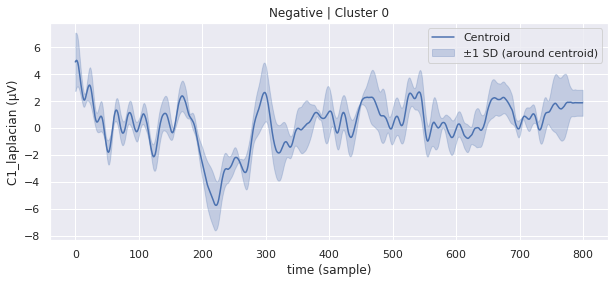

In [148]:
plot_cluster_centroid(
    neg_signals_for_channel[neg_labels==cluster], 
    neg_signals_for_channel[neg_centroids_indices[cluster]],
    CHANNEL, 
    f'Negative | Cluster {cluster}'
)

## Центроиды для эпох

### AffinityPropagation

In [26]:
NAME = 'ЛММ'

In [27]:
smoother = ChannelSmoother()
distance_calculator = DistanceCalculator('correlation')
averager = EpochClusterer()

In [37]:
epochs = processed_signals[1][NAME]['positive_epochs']

In [38]:
epochs = smoother.smoothe(epochs)

In [39]:
centroids = averager.average(epochs, distance_calculator)

In [40]:
len(centroids)

13

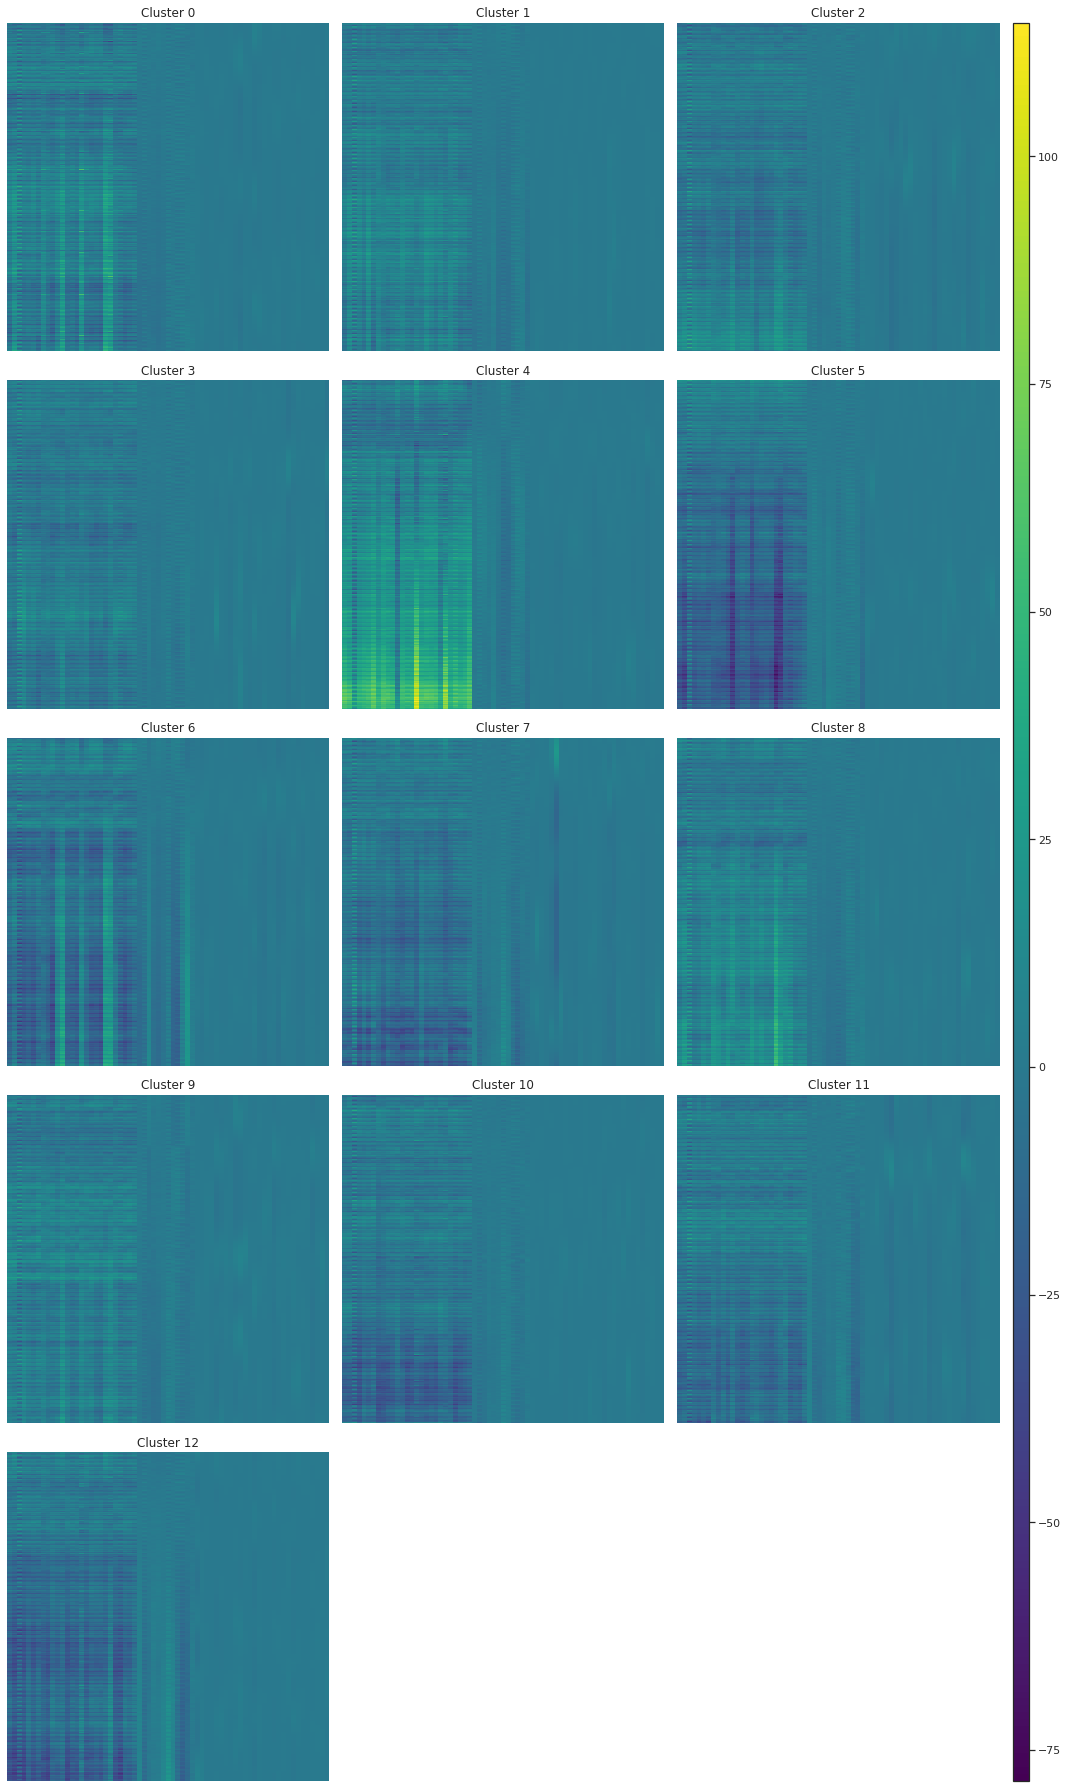

In [41]:
n_clusters = len(centroids)
fig_cols = 3
fig_rows = int(np.ceil(n_clusters / fig_cols))

sns.set(style="white")
fig = plt.figure(figsize=(5*fig_cols, 5*fig_rows))

# отдельный столбец для colorbar
gs = fig.add_gridspec(fig_rows, fig_cols + 1, width_ratios=[1]*fig_cols + [0.05])

axes = []
for r in range(fig_rows):
    for c in range(fig_cols):
        ax = fig.add_subplot(gs[r, c])
        axes.append(ax)

# оси colorbar'а (все строки, последний столбец)
cax = fig.add_subplot(gs[:, -1])

vmin = np.min(centroids)
vmax = np.max(centroids)

last_mappable = None
for k, ax in enumerate(axes[:n_clusters]):
    m = sns.heatmap(
        centroids[k],
        ax=ax,
        vmin=vmin, vmax=vmax,
        cmap="viridis",
        cbar=False,
        xticklabels=False, yticklabels=False,
    )
    ax.set_title(f"Cluster {k}")
    last_mappable = ax.collections[0]

for ax in axes[n_clusters:]:
    ax.axis("off")

fig.colorbar(last_mappable, cax=cax)
plt.tight_layout()
# plt.savefig('pos_epochs_heatmap.png', transparent=True, bbox_inches='tight')
plt.show()

In [42]:
averager.labels

array([ 0,  4,  0,  0, 11,  7,  9,  1,  5,  6,  1,  4,  1, 11, 10,  1,  2,
        1,  5,  2, 10, 10,  9,  8,  7,  8,  5, 12,  1,  0,  2, 10,  4,  2,
        0,  3, 12,  5, 11, 11,  4,  1,  5,  4,  9, 12,  2,  5, 11,  3,  6,
        7,  0, 11, 10,  1, 10,  0,  7,  8, 10,  3,  3, 11,  3,  5,  4,  2,
       12,  6, 12,  1,  9, 11,  2,  2,  7,  5, 10, 11, 11,  0,  5,  7, 10,
        7,  2,  4, 12,  8, 12, 12])

In [43]:
np.unique(averager.labels, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 array([ 8,  9,  9,  5,  7,  9,  3,  7,  4,  4,  9, 10,  8]))

In [44]:
cluster = 4
epochs_in_cluster = list(compress(epochs, averager.labels == cluster))
cluster_size = np.sum(averager.labels == cluster)

In [45]:
cluster_size

7

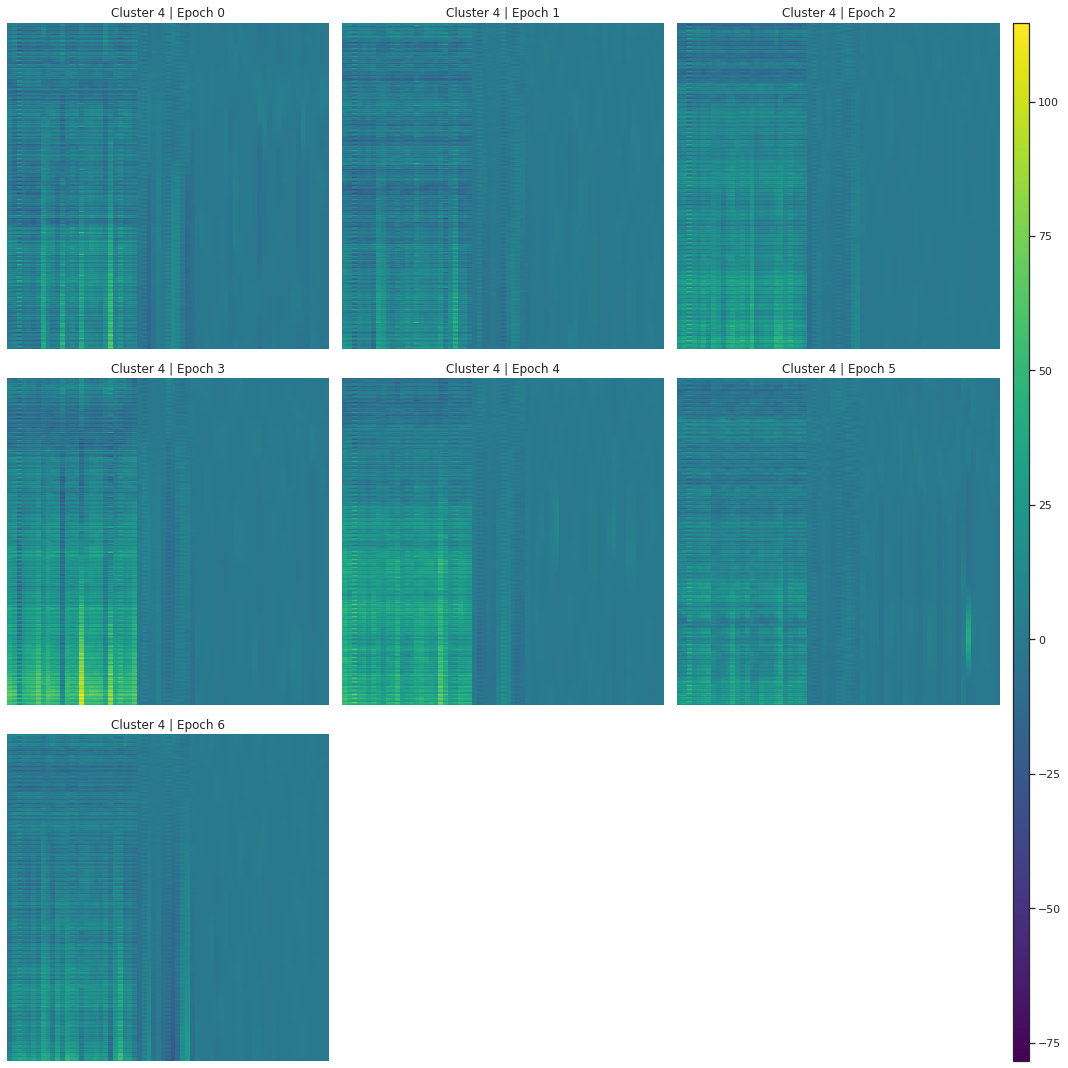

In [46]:
fig_cols = 3
fig_rows = int(np.ceil(cluster_size / fig_cols))

sns.set(style="white")
fig = plt.figure(figsize=(5*fig_cols, 5*fig_rows))

# отдельный столбец для colorbar
gs = fig.add_gridspec(fig_rows, fig_cols + 1, width_ratios=[1]*fig_cols + [0.05])

axes = []
for r in range(fig_rows):
    for c in range(fig_cols):
        ax = fig.add_subplot(gs[r, c])
        axes.append(ax)

# оси colorbar'а (все строки, последний столбец)
cax = fig.add_subplot(gs[:, -1])

# используем те же vmin/vmax для согласованности
vmin = np.min(centroids)
vmax = np.max(centroids)

last_mappable = None
for k, ax in enumerate(axes[:cluster_size]):
    m = sns.heatmap(
        epochs_in_cluster[k],
        ax=ax,
        vmin=vmin, vmax=vmax,
        cmap="viridis",
        cbar=False,
        xticklabels=False, yticklabels=False,
    )
    ax.set_title(f"Cluster {cluster} | Epoch {k}")
    last_mappable = ax.collections[0]

for ax in axes[cluster_size:]:
    ax.axis("off")

fig.colorbar(last_mappable, cax=cax)
plt.tight_layout()
# plt.savefig('pos_epochs_heatmap.png', transparent=True, bbox_inches='tight')
plt.show()

In [47]:
cluster = 5
epochs_in_cluster = list(compress(epochs, averager.labels == cluster))
cluster_size = np.sum(averager.labels == cluster)

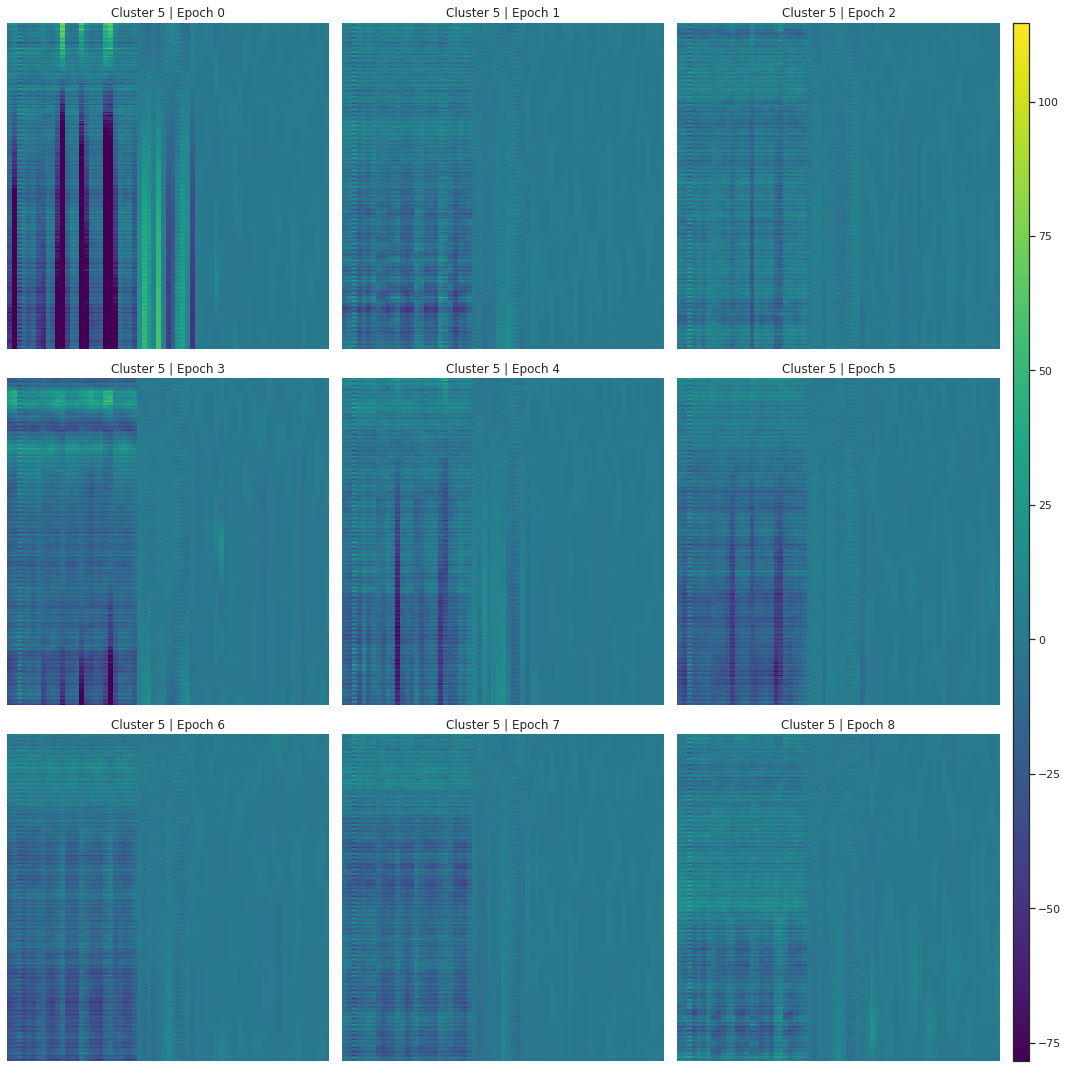

In [48]:
fig_cols = 3
fig_rows = int(np.ceil(cluster_size / fig_cols))

sns.set(style="white")
fig = plt.figure(figsize=(5*fig_cols, 5*fig_rows))

# отдельный столбец для colorbar
gs = fig.add_gridspec(fig_rows, fig_cols + 1, width_ratios=[1]*fig_cols + [0.05])

axes = []
for r in range(fig_rows):
    for c in range(fig_cols):
        ax = fig.add_subplot(gs[r, c])
        axes.append(ax)

# оси colorbar'а (все строки, последний столбец)
cax = fig.add_subplot(gs[:, -1])

# используем те же vmin/vmax для согласованности
vmin = np.min(centroids)
vmax = np.max(centroids)

last_mappable = None
for k, ax in enumerate(axes[:cluster_size]):
    m = sns.heatmap(
        epochs_in_cluster[k],
        ax=ax,
        vmin=vmin, vmax=vmax,
        cmap="viridis",
        cbar=False,
        xticklabels=False, yticklabels=False,
    )
    ax.set_title(f"Cluster {cluster} | Epoch {k}")
    last_mappable = ax.collections[0]

for ax in axes[cluster_size:]:
    ax.axis("off")

fig.colorbar(last_mappable, cax=cax)
plt.tight_layout()
# plt.savefig('pos_epochs_heatmap.png', transparent=True, bbox_inches='tight')
plt.show()